<a href="https://colab.research.google.com/github/Kauboimausu/practica4-nlps/blob/main/practica4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


# Práctica 4: Redes Neuronales Recurrentes y Procesamiento de Lenguaje Natural (NLP)

Esta práctica tiene como objetivo comprender el flujo de trabajo del NLP, desde la conversión de texto a representaciones numéricas (*tokens*), hasta el diseño, entrenamiento y evaluación crítica de una red neuronal recurrente (LSTM) aplicada al análisis de sentimiento en español.

**Conjunto de datos:** *IMDB Dataset of 50K Movie Reviews - Spanish*
(Descargar de: https://www.kaggle.com/datasets/luisdiegofv97/imdb-dataset-of-50k-movie-reviews-spanish)

**Instrucciones:**
> Implementa lo que se pide a continuación de manera individual. El código, las gráficas y las respuestas a las preguntas de análisis deben quedar plasmadas en este mismo Notebook. Se recomienda utilizar un subconjunto de los datos (ej. 10,000 reseñas).


In [2]:
import sys
import os

import torch
import torchvision
import numpy as np
import pandas as pd
import kagglehub

IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    %pip install -q torchmetrics
else: 
    if torch.version.hip is not None:  
        os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

---

## Parte 1: Del texto a tokens [1.5 puntos]

### Recordando qué es la tokenización
Los modelos de aprendizaje profundo no pueden procesar texto crudo (cadenas de caracteres). Asumen que el texto ha sido *tokenizado* y codificado como vectores numéricos. Históricamente, existen tres enfoques principales:

1. La _Character Tokenization_ (Nivel Carácter) se alimenta cada carácter individualmente al modelo. Ignora cualquier estructura lingüística. Su gran desventaja es que el modelo debe aprender a formar palabras desde cero, requiriendo demasiada memoria y datos.
2. La _Word Tokenization_ (Nivel Palabra) divide el texto usando espacios (ej. `text.split()`). El problema es que los signos de puntuación se adhieren a las palabras (ej. `"NLP."` se vuelve un token distinto a `"NLP"`). Dado que los idiomas tienen conjugaciones y declinaciones, el vocabulario crece a millones. Para evitar redes inmensas, se limita el vocabulario (ej. las 50,000 palabras más comunes) y el resto se clasifica como un token desconocido `[UNK]`. Esto causa pérdida de información.
3. La _Subword Tokenization_ (El estándar moderno) combina los mejores aspectos de los anteriores (usado por BERT, GPT, etc.). Divide las palabras raras en subunidades lingüísticas y mantiene enteras las palabras frecuentes. Por ejemplo, la palabra `"tokenizing"` podría dividirse en `"token"` y `"##izing"`.

### 1.1 Implementación y comparación [1.5 puntos]
Considera las siguientes tres oraciones complejas en español:

In [4]:
textos = [
    "dos horas de mi vida que no voy a recuperar!!! y ni siquiera aprendí nada...",
    "hmmm :( me gustó más pensar en la película que verla.",
    "que?? esto con 20 minutos menos sería otra cosa completamente distinta ajjaj."
]

**a)** Implementa una función básica de *Word Tokenization* en Python usando `.split()`. Muestra la lista de palabras generada para cada texto. Observa qué sucede con los signos de puntuación.

In [5]:
# [TU CÓDIGO AQUÍ] Word tokenization manual
palabras_conocidas = []
for review in textos:
    palabras_conocidas.extend(review.split())
diccionario = sorted(set(palabras_conocidas + ["[PAD]", "[UNK]"]))
word2idx = {palabra: idx for idx, palabra in enumerate(diccionario)}
idx2word = {idx: palabra for palabra, idx in word2idx.items()}
print(f"Diccionario conocido:")
for k, v in word2idx.items():
    print(f"{k!r:20s}  -->  {v}")

Diccionario conocido:
'20'                  -->  0
':('                  -->  1
'[PAD]'               -->  2
'[UNK]'               -->  3
'a'                   -->  4
'ajjaj.'              -->  5
'aprendí'             -->  6
'completamente'       -->  7
'con'                 -->  8
'cosa'                -->  9
'de'                  -->  10
'distinta'            -->  11
'dos'                 -->  12
'en'                  -->  13
'esto'                -->  14
'gustó'               -->  15
'hmmm'                -->  16
'horas'               -->  17
'la'                  -->  18
'me'                  -->  19
'menos'               -->  20
'mi'                  -->  21
'minutos'             -->  22
'más'                 -->  23
'nada...'             -->  24
'ni'                  -->  25
'no'                  -->  26
'otra'                -->  27
'película'            -->  28
'pensar'              -->  29
'que'                 -->  30
'que??'               -->  31
'recuperar!!!'        -->  3

El método __split__ toma como default splitter los espacios, entonces "nada..." es detectado cómo su propía palabra, diferente de "nada", "nada.", "nada..", etc... 

Esto claramente no es la forma óptima de tokenizar, al menos lógicamente tiene sentido para mí que los tokens sean "nada" y "..."

También es obvio ver cómo esto podría causar un problema para las risas, que pueden ser erraticas al escribirse por naturaleza de lo que indican.

**b)** usa la librería `transformers` de Hugging Face. Carga el tokenizador pre-entrenado en español `dccuchile/bert-base-spanish-wwm-uncased`. Aplícalo a las 3 oraciones e imprime los tokens resultantes (puedes usar el método `convert_ids_to_tokens`).
*   puedes leer sobre este tokenizador y el modelo asociado en su [página de Hugging Face](https://huggingface.co/dccuchile/bert-base-spanish-wwm-uncased).

In [6]:
#[TU CÓDIGO AQUÍ] Subword tokenization usando AutoTokenizer de transformers
from transformers import BertTokenizer

# importamos nuestro tokenizer preentrenado
tokenizador_espanol = BertTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased", do_lower_case=False)

for review in textos:
    tokens = tokenizador_espanol.encode(review)
    print(f"Review: {review}")
    print(f"Tokenización: {tokenizador_espanol.convert_ids_to_tokens(tokens)}")
    print(f"Decodificación: {tokenizador_espanol.decode(tokens)}")
    print("\n")

Review: dos horas de mi vida que no voy a recuperar!!! y ni siquiera aprendí nada...
Tokenización: ['[CLS]', 'dos', 'horas', 'de', 'mi', 'vida', 'que', 'no', 'voy', 'a', 'recuperar', '!', '!', '!', 'y', 'ni', 'siquiera', 'aprendí', 'nada', '.', '.', '.', '[SEP]']
Decodificación: [CLS] dos horas de mi vida que no voy a recuperar!!! y ni siquiera aprendí nada... [SEP]


Review: hmmm :( me gustó más pensar en la película que verla.
Tokenización: ['[CLS]', 'hmm', '##m', ':', '(', 'me', 'gustó', 'más', 'pensar', 'en', 'la', 'película', 'que', 'verla', '.', '[SEP]']
Decodificación: [CLS] hmmm : ( me gustó más pensar en la película que verla. [SEP]


Review: que?? esto con 20 minutos menos sería otra cosa completamente distinta ajjaj.
Tokenización: ['[CLS]', 'que', '?', '?', 'esto', 'con', '20', 'minutos', 'menos', 'sería', 'otra', 'cosa', 'completamente', 'distinta', 'aj', '##ja', '##j', '.', '[SEP]']
Decodificación: [CLS] que?? esto con 20 minutos menos sería otra cosa completamente distint




**c)** Responde, basado en los resultados impresos, ¿cómo manejó el tokenizador de HuggingFace los signos de puntuación, los acentos, etc? comenta todo lo que observas

Los acentos los maneja como el tokenizador manual, más o menos, "gustó" y "sería" son tokens únicos, en el sentido que son reconocidos como su propio token, y no "gust" + "ó".

Los signos de puntuación parecen ser manejados como su propia cosa cada uno, algo que no sé si es lo más preciso ya que ":(" es básicamente una palabra (aunque igual podría complicarse al considerar cosas como ":((", por ejemplo). 

Para las risas podemos ver que más o menos resuelve este problema con tokens "##ja", lo cual probablemente es acertado ya que "ja" se puede repetir muchas veces, llegando a cambiar el resultado semántico.


## Parte 2: Preparación de datos y tensores [1.5 puntos]

Para poder procesar lotes (*batches*) de texto en una red neuronal, todas las secuencias deben tener la misma longitud. Para esto utilizamos **Padding** (relleno con ceros, representados por el token `[PAD]`) para las oraciones cortas, y **Truncamiento** para las oraciones demasiado largas.

**a)** Carga el archivo `.csv` de IMDB. Convierte las etiquetas de sentimiento a formato numérico (positivo = 1, negativo = 0).


In [7]:
path = kagglehub.dataset_download("luisdiegofv97/imdb-dataset-of-50k-movie-reviews-spanish")
reviews_df = pd.read_csv(path + "/IMDB Dataset SPANISH.csv", usecols=["review_es", "sentimiento"])
reviews_df.head(2)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews-spanish' dataset.


,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo


Bien, ya tenemos nuestros datos en un dataframe, pero queremos que la columna de sentimiento sea un valor númerico 0 o 1, no texto, podemos hacer esto muy fácilmente con pandas:

In [8]:
reviews_df["sentimiento"] = reviews_df["sentimiento"].map({"positivo": 1, "negativo": 0})
reviews_df.head(2)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,1
1,Una pequeña pequeña producción.La técnica de f...,1



**b)** Utiliza el `AutoTokenizer` del inciso anterior para tokenizar todo tu conjunto de datos. Asegúrate de aplicar `padding=True`, `truncation=True` y definir un `max_length` razonable (ej. 150 o 250 tokens).

**c)** Construye los objetos `TensorDataset` y `DataLoader` de PyTorch para tus conjuntos de entrenamiento (80%) y prueba (20%). Recuerda incluir tanto los `input_ids` como la etiqueta.

(En mi caso también agregué un conjunto de validación que equivalé al 10% del conjunto total, por lo tanto es 70% entrenamiento, 10% validación, 20% prueba)

In [9]:
from sklearn.model_selection import train_test_split

train_valid_size = len(reviews_df) * 80 // 100
train_size = len(reviews_df) * 70 // 100
imdb_train_valid_set, imdb_test_set = train_test_split(reviews_df, train_size=train_valid_size, shuffle=True, random_state=21)
imdb_train_set, imdb_valid_set = train_test_split(imdb_train_valid_set, train_size=train_size, shuffle=True, random_state=21)

In [10]:
print(imdb_test_set.iloc[0]["review_es"])
print("---------")
print(imdb_test_set.iloc[0]["sentimiento"])

Me pregunto cuántos Mini Cooper Automobiles se vendieron gracias a esta película? No podía evitar agregar a las ventas de este pequeño automóvil, que aparece en esta película, junto con un ataque atractivo. Esta es una película de Heist-and-Chase muy, muy entretenida. Cuenta con un elenco "Cool" con Mark Wahlberg, Charlize Theron, Edward Norton, Seth Green y Jason Statham. La mejor escena de Chase está justo al principio con una búsqueda en barco en Venecia, Italia. La película no exagera la violencia, tiene un guión bastante inteligente (con algunas excepciones cortas). Cuenta con caracteres interesantes y está muy bien firme. El juego de gatos y ratones entre los personajes de Norton y Theron es suspenso y divertido de ver. Sin embargo, de nuevo, nos manipulamos en alentarse para los delincuentes retratados como "los buenos". ¿Cuántas veces ha sucedido esto desde los días de "Butch Cassidy y The Sundance Kid" en la década de 1960? Es retorcido Hollywood, para ti. Aquí, uno de los del

In [11]:
# [TU CÓDIGO AQUÍ] Carga de pandas, tokenización masiva y creación de DataLoaders
from torch.utils.data import DataLoader

def collate_fn(batch, tokenizer=tokenizador_espanol):
    reviews = [review["review_es"] for review in batch]
    labels = [[review["sentimiento"]] for review in batch]
    encodings = tokenizer(reviews, padding=True, truncation=True, max_length=200, return_tensors="pt")
    labels = torch.tensor(labels, dtype=torch.float32)

    return encodings, labels

batch_size = 32

imdb_train_loader = DataLoader(imdb_train_set.to_dict("records"), batch_size=batch_size, collate_fn=collate_fn)
imdb_valid_loader = DataLoader(imdb_valid_set.to_dict("records"), batch_size=batch_size, collate_fn=collate_fn)
imdb_test_loader = DataLoader(imdb_test_set.to_dict("records"), batch_size=batch_size, collate_fn=collate_fn)

## Parte 3: Construcción de la memoria (arquitectura LSTM) [2.5 puntos]

El mayor reto al programar Redes Neuronales Recurrentes es comprender cómo fluyen las dimensiones de los tensores a través del tiempo.

Implementa una clase `ModeloAnalisisSentimiento` que herede de `nn.Module`. Debe contener:
1. Una capa `nn.Embedding`.
2. Una capa `nn.LSTM` (puedes decidir si hacerla bidireccional, número de capas ocultas, etc.).
3. Una capa `nn.Linear` de salida.

Lo siguiente es obligatorio, tu método `forward` debe aceptar un parámetro booleano `print_shapes=False`. Cuando sea `True`, el modelo debe imprimir con un `print()` la dimensión del tensor (`.shape`) exactamente en estos tres momentos:
- A la salida de la capa de Embedding.
- A la salida de la capa LSTM (imprime la dimensión de `output`, del `hidden_state` y del `cell_state`).
- A la salida de la capa Lineal.

Una vez definida la clase, pasa un *batch* de prueba por tu modelo con `print_shapes=True` y **explica en texto** qué significa cada uno de los números en las dimensiones impresas (ej. *"El tamaño [32, 150, 128] significa[tamaño de batch, longitud de secuencia, dimensión del embedding]"*).

In [12]:
import torch
import torch.nn as nn
torch.manual_seed(21)

class ModeloAnalisisSentimiento(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_id=0):
        super().__init__()
        # [TU CÓDIGO AQUÍ] Definir las capas: Embedding, LSTM, Dropout, Linear
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout,
            batch_first=True
        )
        self.clasificador = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, attention_mask=None, print_shapes=False):
        # Nota: La función de activación Sigmoid para obtener la probabilidad
        # se aplicará fuera del modelo, o implícitamente en la función de pérdida.
        # El modelo debe devolver los logits crudos.

        # [TU CÓDIGO AQUÍ] Implementar el forward pass y los prints condicionales
        embedding = self.embedding(text)

        if attention_mask is not None:
            lengths = attention_mask.sum(dim=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(embedding, lengths, batch_first=True, enforce_sorted=False)
            salida_seq, (h_n, c_n) = self.lstm(packed)
        else:
            salida_seq, (h_n, c_n) = self.lstm(embedding)

        estado_final = h_n[-1]
        logits = self.clasificador(estado_final)

        if print_shapes:
            print(f"Forma de salida de embeddings: {embedding.shape}")
            print(f"Forma de salida de output: {salida_seq.shape}")
            print(f"Forma de salida de hidden state: {h_n.shape}")
            print(f"Forma de salida de cell state: {c_n.shape}")
            print(f"Forma de salida de salida: {logits.shape}")

        return logits

In [13]:
# [TU CÓDIGO AQUÍ] Instanciar el modelo y pasar un batch del dataloader con print_shapes=True
modelo_feik = ModeloAnalisisSentimiento(
    vocab_size=tokenizador_espanol.vocab_size,
    embed_dim=128,
    hidden_dim=20,
    output_dim=1,
    n_layers=3,
    bidirectional=False,
    dropout=0.3
)
X_feik = torch.randint(1, 200, (30, 100))

with torch.no_grad():
    modelo_feik.forward(X_feik, print_shapes=True)

Forma de salida de embeddings: torch.Size([30, 100, 128])
Forma de salida de output: torch.Size([30, 100, 20])
Forma de salida de hidden state: torch.Size([3, 30, 20])
Forma de salida de cell state: torch.Size([3, 30, 20])
Forma de salida de salida: torch.Size([30, 1])


- Embeddings: 30 ejemplares en el batch, 100 es la longitud de cada batch, 128 es la dimensión del embedding
- Output: 30 ejemplares en el batch, 100 longitud de cada batch, amplitud de las capas escondidas
- Hidden State: 3 capas ocultas, 30 ejemplares en el batch, 20 neuronas en las capas ocultas
- Cell State: igual que hidden state
- Salida: 30 ejemplares en el batch, 1 salida cada una

## Parte 4: Entrenamiento y evaluación [2 puntos]

Entrena la red LSTM.

**a)** Define tu optimizador (Adam recomendado) y tu función de pérdida (usualmente `BCEWithLogitsLoss` para clasificación binaria).


**b)** Realiza el ciclo de entrenamiento por un mínimo de 3 a 5 épocas.


**c)** Muestra en una gráfica cómo evoluciona la pérdida de entrenamiento y la de validación/prueba a lo largo de las épocas.


**d)** Reporta el *Accuracy* final en el conjunto de prueba.


In [29]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, 
                              max_epochs, patience_epochs=5, checkpoint_path=None, scheduler=None):
    metric.reset()
    checkpoint_path = checkpoint_path or "my_checkpoint.pt"
    # best_valid_loss = float("inf")
    best_valid_metric = 0
    loss_histories = {"train_losses": [], "validation_losses": []}
    metric_histories = {"train_metrics": [], "validation_metrics": []}
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        metric.reset()
        total_train_loss = 0
        # Entrenamiento
        for X_batch, y_batch in train_loader:
            input_ids, attention_mask, y_batch = X_batch["input_ids"].to(device), X_batch["attention_mask"].to(device), y_batch.to(device)
            # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(input_ids, attention_mask)
            batch_loss = criterion(preds, y_batch)
            total_train_loss += batch_loss.item()
            batch_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            metric.update(preds, y_batch)
        train_metric = metric.compute().item()

        # Prueba en conjunto de validación
        total_validation_loss = 0
        model.eval() # importante cambiar a modo de evaluación
        metric.reset() # Reseteamos las métricas entre conjuntos de entrenamiento y validación
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                input_ids, attention_mask, y_batch = X_batch["input_ids"].to(device), X_batch["attention_mask"].to(device), y_batch.to(device)
                # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(input_ids, attention_mask)
                batch_loss = criterion(preds, y_batch)
                total_validation_loss += batch_loss.item()
                metric.update(preds, y_batch)
        validation_metric = metric.compute().item()

        # Calculamos la pérdida para ambos conjuntos 
        mean_train_loss = total_train_loss / len(train_loader)
        mean_validation_loss = total_validation_loss / len(valid_loader)

        loss_histories["train_losses"].append(mean_train_loss)
        loss_histories["validation_losses"].append(mean_validation_loss)

        metric_histories["train_metrics"].append(train_metric)
        metric_histories["validation_metrics"].append(validation_metric)

        if scheduler is not None:
            scheduler.step()

        print(f"\rEpoch {epoch + 1}/{max_epochs},                      "
              f"Pérdida de Entrenamiento: {loss_histories['train_losses'][-1]:.4f}, "
              f"Pérdida de Validación: {loss_histories['validation_losses'][-1]:.4f}, "
              f"Métrica de Entrenamiento: {metric_histories['train_metrics'][-1]:.2%}, "
              f"Métrica de Validación: {metric_histories['validation_metrics'][-1]:.2%}")

        # Pasos de early stopping
        # En este caso queremos maximizar precisión, entonces lo haremos por precisión
        if validation_metric > best_valid_metric:
            # nos aseguramos de regresar el mejor modelo, no el último
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
            best_valid_metric = validation_metric
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement == patience_epochs:
                print(f"Sin mejora en conjunto de validación por {patience_epochs} épocas")
                print(f"Parando entrenamiento en época {epoch}")

                break
        
    model.load_state_dict(torch.load(checkpoint_path))
    return loss_histories, metric_histories
    

In [15]:
import torchmetrics

In [28]:
# Esto lo puse porque crasheaba mi kernel local pero al final lo terminé haciendo en colab ;-;
print(torch.cuda.memory_allocated() / 1024**2, "MB")
print(torch.cuda.memory_reserved() / 1024**2, "MB")

170.79833984375 MB
408.0 MB


In [30]:
torch.manual_seed(21)

vocab_size = tokenizador_espanol.vocab_size
modelo_imdb = ModeloAnalisisSentimiento(
    vocab_size=tokenizador_espanol.vocab_size,
    embed_dim=128,
    hidden_dim=128,
    output_dim=1,
    n_layers=2,
    bidirectional=False,
    dropout=0.3
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.NAdam(modelo_imdb.parameters())
accuracy = torchmetrics.Accuracy(task="binary").to(device)

loss_hist, metric_hist = train(modelo_imdb, optimizer, criterion, accuracy, imdb_train_loader, imdb_valid_loader, 10, 5)

Epoch 1/10,                      Pérdida de Entrenamiento: 0.6369, Pérdida de Validación: 0.6237, Métrica de Entrenamiento: 62.44%, Métrica de Validación: 69.24%
Epoch 2/10,                      Pérdida de Entrenamiento: 0.4267, Pérdida de Validación: 0.3987, Métrica de Entrenamiento: 80.54%, Métrica de Validación: 81.52%
Epoch 3/10,                      Pérdida de Entrenamiento: 0.3108, Pérdida de Validación: 0.4019, Métrica de Entrenamiento: 86.85%, Métrica de Validación: 83.12%
Epoch 4/10,                      Pérdida de Entrenamiento: 0.2294, Pérdida de Validación: 0.4148, Métrica de Entrenamiento: 90.99%, Métrica de Validación: 83.94%
Epoch 5/10,                      Pérdida de Entrenamiento: 0.1599, Pérdida de Validación: 0.4764, Métrica de Entrenamiento: 94.17%, Métrica de Validación: 84.04%
Epoch 6/10,                      Pérdida de Entrenamiento: 0.1072, Pérdida de Validación: 0.5418, Métrica de Entrenamiento: 96.41%, Métrica de Validación: 83.10%
Epoch 7/10,                 

In [31]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

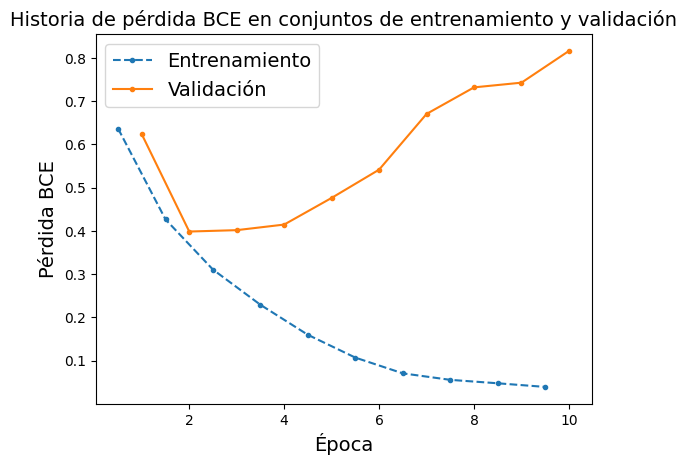

In [32]:
n_epocas = len(loss_hist["train_losses"])
plt.plot(np.arange(n_epocas) + 0.5, loss_hist["train_losses"], ".--", label="Entrenamiento")
plt.plot(np.arange(n_epocas) + 1.0, loss_hist["validation_losses"], ".-", label="Validación")
plt.xlabel("Época")
plt.ylabel("Pérdida BCE")
plt.title("Historia de pérdida BCE en conjuntos de entrenamiento y validación")
plt.legend()
plt.show()

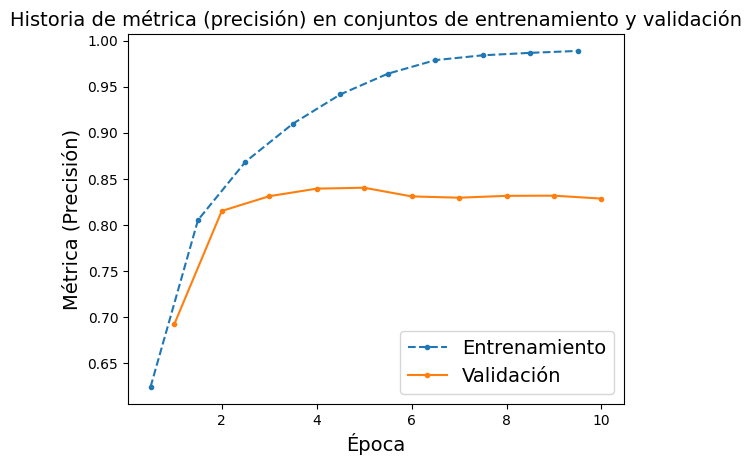

In [33]:
n_epocas = len(metric_hist["train_metrics"])
plt.plot(np.arange(n_epocas) + 0.5, metric_hist["train_metrics"], ".--", label="Entrenamiento")
plt.plot(np.arange(n_epocas) + 1.0, metric_hist["validation_metrics"], ".-", label="Validación")
plt.xlabel("Época")
plt.ylabel("Métrica (Precisión)")
plt.title("Historia de métrica (precisión) en conjuntos de entrenamiento y validación")
plt.legend()
plt.show()

Y esos son nuestros historiales de entrenamiento para la métrica, en este caso precisión, y la pérdida en ambos conjuntos, el de entrenamiento y el de validación. Implementé early stopping y también me aseguré de guardar los pesos del mejor modelo y regresar justo esos pesos. También se puede utilizar un scheduler pero yo no lo utilicé. Ahora veamos la evaluación del modelo en el conjunto de prueba:

In [35]:
def evaluar_modelo(model, metric, data_loader):
    model.eval() # importante cambiar a modo de evaluación
    metric.reset() # Reseteamos las métricas entre conjuntos de entrenamiento y validación
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            input_ids, attention_mask, y_batch = X_batch["input_ids"].to(device), X_batch["attention_mask"].to(device), y_batch.to(device)
            # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(input_ids, attention_mask)
            metric.update(preds, y_batch)
    return metric.compute().item()

In [36]:
print(f"Precisión en conjunto de prueba: {evaluar_modelo(modelo_imdb, accuracy, imdb_test_loader)}")

Precisión en conjunto de prueba: 0.8334000110626221


## Parte 5: Análisis y "amnesia" temporal [1.5 puntos]


Las LSTM procesan la información de manera secuencial, asumiendo que el orden de las palabras importa. ¿Qué sucede si alteramos la naturaleza del tiempo en las oraciones?

**a)** Toma tu conjunto de prueba y **vueltea cronológicamente** el orden de todas las palabras en los textos (ej. *"La película fue mala"* $\to$ *"mala fue película La"*). Tokeniza este texto invertido y evalúalo usando tu modelo ya entrenado (NO vuelvas a entrenar el modelo).


**b)** Reporta el nuevo *Accuracy* sobre los datos invertidos.


**c)** **Análisis:** ¿El rendimiento cayó mucho al nivel del azar (50%) o se mantuvo relativamente alto? Explica teóricamente por qué la memoria oculta (*hidden state*) de tu LSTM reaccionó de esta manera.


In [ ]:
def collate_and_permute_fn(batch, tokenizer=tokenizador_espanol):
    reviews = [review["review_es"] for review in batch]
    reviews_split = [review.split() for review in reviews]
    reviews_flipped = []
    for review_split in reviews_split:
        midpoint = len(review_split) // 2
        izquierda = [review_split[i] for i in range(midpoint+1)]
        izquierda = " ".join(izquierda)
        derecha = [review_split[i] for i in range(midpoint, len(review_split))]
        derecha = " ".join(derecha)
        reviews_flipped.append(derecha + " " + izquierda)

    labels = [[review["sentimiento"]] for review in batch]
    encodings = tokenizer(reviews_flipped, padding=True, truncation=True, max_length=200, return_tensors="pt")
    labels = torch.tensor(labels, dtype=torch.float32)

    return encodings, labels

batch_size = 32

imdb_flipped_test_loader = DataLoader(imdb_test_set.to_dict("records"), batch_size=batch_size, collate_fn=collate_and_permute_fn)

In [68]:
print(f"Precisión en conjunto de prueba volteado: {evaluar_modelo(modelo_imdb, accuracy, imdb_flipped_test_loader)}")

['y' 'The' 'Sundance' 'Kid"' 'en' 'la' 'década' 'de' '1960?' 'Es'
 'retorcido' 'Hollywood,' 'para' 'ti.' 'Aquí,' 'uno' 'de' 'los'
 'delincuentes' '(Norton)' 'robó' 'y' 'mató' 'a' 'la' 'figura' 'del'
 'líder' 'y' 'padre' '(Donald' 'Sutherland)' 'de' 'la' 'pandilla,' 'por'
 'lo' 'que' 'es' 'lo' 'peor' 'del' 'grupo' 'y' 'el' 'villano' 'de' 'la'
 'película.' 'Además,' 'el' 'personaje' 'de' 'Theron' 'está' 'en' 'el'
 'modo' 'de' 'Hollywood' 'típicamente' 'sobrepeminista' 'en' 'el' 'que'
 'las' 'mujeres' 'pueden' 'hacer' 'todas' 'las' 'cosas' '(incluyendo'
 'conducir' 'un' 'automóvil)' 'mejor' 'que' 'un' 'hombre.' 'Una' 'tercera'
 'irritación' 'menor' 'es' 'la' 'presentación' 'de' 'Seth' 'Green,' 'la'
 'actitud' 'de' 'Smart-Ass,' 'que' 'también' 'debemos' 'seguir' 'adelante'
 'porque' 'es' 'cadera' 'y' 'fresca.' 'A' 'pesar' 'de' 'estos'
 'obstáculos,' 'es' 'una' 'película' 'extremadamente' 'entretenida' 'y'
 'tampoco' 'no' 'está' 'sobre' 'la' 'profanidad' 'o' 'el' 'sexo' '...'
 'y,' 'sí,' 'e

RuntimeError: Predictions and targets are expected to have the same shape, but got torch.Size([8188, 1]) and torch.Size([32, 1]).

: 

## Parte 6: Hackeando tu propio modelo [1 puntos]

Un modelo puede tener métricas altísimas en el conjunto de prueba, pero fallar estrepitosamente en el lenguaje real del día a día debido al sarcasmo, ironía o frases coloquiales.

**a)** Inventa **5 reseñas originales (escritas por ti)**. El objetivo es que logres engañar a tu propio modelo.
- Si la reseña es positiva (para un humano), el modelo debe predecir equivocadamente "Negativo".
- Si la reseña es negativa (para un humano), el modelo debe predecir equivocadamente "Positivo".
- *Regla:* Tienen que ser frases coherentes en español, no palabras aleatorias. Intenta usar sarcasmo, falsos contrastes, modismos o frases complejas. (Ej. *"Una obra de arte perfecta si lo que buscas es dormir"*).

**b)** Pasa tus 5 frases por el modelo, imprime la probabilidad de predicción.


**c)** **Discusión:** Explica brevemente, para cada frase, por qué crees que el modelo falló. ¿Qué palabra o estructura confundió a las compuertas de actualización (update gates) de la LSTM y diluyó el verdadero sentimiento en el estado de la celda?


In [44]:
#[TU CÓDIGO AQUÍ] Definir 5 textos originales adversarios, hacer inferencia e imprimir resultados

frases_prueba = [
    # falsos_positivos
    "Woooooooooooooooooow enserio una de las mejores peliculas que he visto en mi vida estoy tan agredecido que me hayan llevado a verla en mi cumpleaños en serio no se me pudo haber ocurrido una mejor manera de pasar mi día, que bueno que aparte pedí ese día libre en serio, wow, like 10/10.",
    "Si crees que esta peli es buena creo que tienes que ver más peliculas..",
    "Esta pelicula me salvó la vida, el año pasado tuve un accidente y me quedé en coma y alguien puso esta pelicula en la tele del hospital y fue entonces que pude pararme para apagar la tele, le debo todo a esta peli",
    "Definitivamente esta es una de las peliculas de todos los tiempos...",
    # falsos negativos
    "Odio esta pelicula! Odio la calidad! Odio su dirección! Odio las excelentes actuaciones, su increíble soundtrack, su gran argumento, todo lo odio!!! Así suenan ustedes en serio",
    # Verdaderos negativos
    "Muy muy muy, excesivamente mala", 
    # Verdaderos positivos
    "Creo que tengo una nueva pelicula favorita", 
    "Hoy revivió el cine"
]

In [37]:
def predecir_sentimiento(modelo, frases, tokenizer=tokenizador_espanol, max_length=200):
    modelo.eval()
    encodings = tokenizer(frases, padding=True, max_length=max_length, return_tensors="pt")
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)

    with torch.no_grad():
        logits = modelo(input_ids, attention_mask).squeeze(-1)
        probs = torch.sigmoid(logits)

    return probs.cpu().tolist()

In [46]:
probas = predecir_sentimiento(modelo_imdb, frases_prueba)
for review, proba in zip(frases_prueba, probas): 
    print(f"Review: '{review:.35s}', probabilidad que sea positiva: {(proba * 100):.2f}%")

Review: 'Woooooooooooooooooow enserio una de', probabilidad que sea positiva: 99.56%
Review: 'Si crees que esta peli es buena cre', probabilidad que sea positiva: 99.17%
Review: 'Esta pelicula me salvó la vida, el ', probabilidad que sea positiva: 86.40%
Review: 'Definitivamente esta es una de las ', probabilidad que sea positiva: 99.41%
Review: 'Odio esta pelicula! Odio la calidad', probabilidad que sea positiva: 98.99%
Review: 'Muy muy muy, excesivamente mala', probabilidad que sea positiva: 27.05%
Review: 'Creo que tengo una nueva pelicula f', probabilidad que sea positiva: 98.79%
Review: 'Hoy revivió el cine', probabilidad que sea positiva: 71.24%


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Creo que más o menos logré engañar al modelo con la excepción del falso negativo que fue enteramente detectada como positiva, aunque en realidad dudo que el modelo sea súper inteligente y realmente sea capaz de discernir que es una review positiva.